## Intallations

In [49]:
#!pip install openai pillow numpy opencv-python jiwer matplotlib pandas requests

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory



In [110]:
!vllm --version

0.25.0+cu129


In [111]:
from openai import OpenAI

VLLM_BASE_URL = "http://127.0.0.1:8000/v1"
MODEL_NAME = "Qwen/Qwen3.5-35B-A3B-GPTQ-Int4"

client = OpenAI(
    base_url=VLLM_BASE_URL,
    api_key="EMPTY"
)

models = client.models.list()

for model in models.data:
    print(model.id)

Qwen/Qwen3.5-35B-A3B-GPTQ-Int4


In [112]:
try:
    models = client.models.list()

    print("Connected to the local vLLM server.")
    print("Available models:")

    for model in models.data:
        print("-", model.id)

except Exception as e:
    print("Could not connect to the vLLM server.")
    print("Make sure vLLM is running on port 8000.")
    print("Error:", e)

Connected to the local vLLM server.
Available models:
- Qwen/Qwen3.5-35B-A3B-GPTQ-Int4


In [113]:
import sys
import torch


print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Torch CUDA:", torch.version.cuda)

Torch version: 2.11.0+cu129
CUDA available: True
GPU: NVIDIA A100 80GB PCIe
Torch CUDA: 12.9


In [114]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
import requests
import pandas as pd
import re
from jiwer import wer, cer
import os

### Image Download

In [115]:
import os
import platform

pages = [8, 9, 38]

base = "https://nlp.fi.muni.cz/projekty/ahisto/book_by_id/494/"

os.makedirs("prompt_images", exist_ok=True)
os_type = platform.system()
print("OS: ", os_type)

for p in pages:
    path = f"prompt_images/{p}.jpg"
    
    if not os.path.exists(path):
        if os_type == "Windows":
            # !curl -o {path} {base}{p}.jpg
            !curl -k -L -o {path} {base}{p}.jpg # ignore certificate verification, follow redirects
        else:
            !wget -O {path} {base}{p}.jpg
    else:
        print(f"Already exists: {path}")

OS:  Linux
Already exists: prompt_images/8.jpg
Already exists: prompt_images/9.jpg
Already exists: prompt_images/38.jpg


## Prompt Design

In [116]:
# bad prompt design - page 8 wer 5.2% cer 0.8%
prompt_text_1 = "Extract all text from this image exactly as written. Preserve line breaks."

In [118]:
# best prompt result -  page 8 WER 1.9%  cer 0.3% 
prompt_text_2 = """
You are an OCR specialist.

Extract every visible character from this image exactly as it appears.

Return plain text only. Preserve the original reading order, line breaks, paragraph breaks, headings, punctuation, capitalization, spelling, abbreviations, umlauts, ß, Roman numerals, page numbers, and hyphenation exactly as printed.

Do not correct spelling or grammar. Do not modernize, normalize, translate, summarize, explain, or infer missing text. Do not merge words that are split by line-ending hyphens.

If any character or word cannot be read with confidence, write [illegible] exactly at that position instead of guessing.

Do not include any comments, Markdown, labels, or additional text. Return only the transcription.
"""

In [119]:
# bad prompt design too much contents - page 8 wer 6.2% cer 0.9%
prompt_text_3 = """
Transcribe this historical German printed page as accurately and literally as possible.

Return plain text only.

This page may contain:
- a running header and page number,
- numbered document entries,
- source descriptions,
- historical German text,
- marginal line numbers,
- marginal dates or reference notes,
- superscript footnote markers,
- and footnotes printed in columns at the bottom.

Use the following transcription order:

1. Transcribe the running header and page number.
2. Transcribe the main page content from top to bottom and left to right.
3. Keep each numbered document entry in its correct sequence.
4. Transcribe footnotes after the main text, reading the left footnote column before the right footnote column.
5. Transcribe marginal annotations separately after the related main text. Do not insert marginal dates, line numbers, or reference labels into the middle of a sentence.

Preserve exactly what is visibly printed, including:
- historical and archaic spelling,
- capitalization,
- punctuation,
- abbreviations,
- umlauts,
- ß,
- Roman numerals,
- square brackets,
- parentheses,
- superscript footnote markers,
- page and volume markers,
- and words divided by hyphens at line endings.

Do not modernize spelling.
Do not correct grammar.
Do not replace archaic words with modern German.
Do not complete partially visible words from context.
Do not translate, summarize, explain, or interpret the text.
Do not add Markdown, headings, comments, labels, or quotation marks that are not printed.
Do not duplicate marginal text.
Do not merge separate text regions into one sentence.

When a character is uncertain, choose the character that is best supported by its visible shape rather than by linguistic probability. Use [illegible] only when no character can be determined visually.

Return only the transcription.
"""

In [120]:
import base64
import mimetypes


def run_ocr_one_image(image_path, prompt_text):
    """
    Sending one image to Qwen3.5 through the local vLLM server
    """

    mime_type, _ = mimetypes.guess_type(image_path)

    if mime_type is None:
        mime_type = "image/jpeg"

    with open(image_path, "rb") as image_file:
        image_base64 = base64.b64encode(
            image_file.read()
        ).decode("utf-8")

    image_data_url = (
        f"data:{mime_type};base64,{image_base64}"
    )

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": image_data_url
                        }
                    },
                    {
                        "type": "text",
                        "text": prompt_text
                    }
                ]
            }
        ],
        temperature=0.0,
        max_tokens=2000,
        extra_body={
            "chat_template_kwargs": {
                "enable_thinking": False
            }
        }
    )

    output_text = response.choices[0].message.content

    if not output_text:
        raise RuntimeError(
            "Qwen returned an empty OCR response."
        )

    return output_text.strip()

### Test one image

In [121]:
test_image_path = "prompt_images/8.jpg"  

ocr_text = run_ocr_one_image(
    test_image_path,
    prompt_text_2
)

print(ocr_text)

Vorwort.

Das Jahr 1885 brachte die erste Fortsetzung des K. Ruprecht mit dem zweiten
Bande von dessen Regierung, dem fünften der ganzen Reihe. Im Jahr 1887 wurde
die dritte Abtheilung der Zeit K. Sigmund's ausgegeben, der neunte Band der Reichs-
tagsakten. Jetzt nach einem Jahre können wir bereits den sechsten Band mittheilen,
welcher zugleich der dritte und Schlußband K. Ruprecht's ist. Hiemit schließt sich die
Lücke, welche in der Regierung dieses Königs noch auszufüllen war, und die sämmt-
lichen bisher erschienenen neun Bände bilden eine ununterbrochene Kette. Mit dem
zehnten Bande, dessen Ausgabe das nächste sein wird, soll dann auch die Periode K.
Sigmund's zu ihrem Ende kommen.

I. Bearbeitung des vorliegenden Bandes.

Die Leitung des Unternehmens ruht wie bisher in der Hand H. v. Sybel's. Von
früheren Mitarbeitern des Bandes, welche bei den Vorarbeiten überhaupt sowie ins-
besondere bei der Anfertigung von Regesten Auszügen und Abschriften thätig waren,
sind zu nennen Kerler, 

In [122]:
# test one page wer cer
import re
import requests
from jiwer import wer, cer

page = 8

def normalize_text(text):
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text


gold_url = f"https://nlp.fi.muni.cz/projekty/ahisto/ocr-output/494/{page}.txt"
gold_text = requests.get(gold_url).text

gold_norm = normalize_text(gold_text)
pred_norm = normalize_text(ocr_text)

wer_score = wer(gold_norm, pred_norm)
cer_score = cer(gold_norm, pred_norm)


print(f"=== Single Page Evaluation (Page {page}) ===")
print(f"WER: {wer_score:.4f} ({wer_score * 100:.2f}%)")
print(f"CER: {cer_score:.4f} ({cer_score * 100:.2f}%)")

=== Single Page Evaluation (Page 8) ===
WER: 0.0199 (1.99%)
CER: 0.0033 (0.33%)


### Try in three images

In [123]:
output_dir = "outputs/prompt_2"
os.makedirs(output_dir, exist_ok=True)

In [124]:
for p in pages:
    print(f"\n==============================")
    print(f"Page {p}")
    print(f"==============================")

    image_path = f"prompt_images/{p}.jpg"
    output_path = os.path.join(output_dir, f"page_{p}.txt")

    output_text = run_ocr_one_image(image_path, prompt_text_2)

    print(output_text)

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(output_text)

    print(f"Saved: {output_path}")


Page 8
Vorwort.

Das Jahr 1885 brachte die erste Fortsetzung des K. Ruprecht mit dem zweiten Bande von dessen Regierung, dem fünften der ganzen Reihe. Im Jahr 1887 wurde die dritte Abtheilung der Zeit K. Sigmund's ausgegeben, der neunte Band der Reichstagsakten. Jetzt nach einem Jahre können wir bereits den sechsten Band mittheilen, welcher zugleich der dritte und Schlußband K. Ruprecht's ist. Hiemit schließt sich die Lücke, welche in der Regierung dieses Königs noch auszufüllen war, und die sämmtlichen bisher erschienenen neun Bände bilden eine ununterbrochene Kette. Mit dem zehnten Bande, dessen Ausgabe das nächste sein wird, soll dann auch die Periode K. Sigmund's zu ihrem Ende kommen.

I. Bearbeitung des vorliegenden Bandes.

Die Leitung des Unternehmens ruht wie bisher in der Hand H. v. Sybel's. Von früheren Mitarbeitern des Bandes, welche bei den Vorarbeiten überhaupt sowie insbesondere bei der Anfertigung von Regesten Auszügen und Abschriften thätig waren, sind zu nennen Kerler

## Evaluation

In [125]:
def normalize_text(text):
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [126]:
results_exp1 = []

gold_base = "https://nlp.fi.muni.cz/projekty/ahisto/ocr-output/494/"

for p in pages:
    print(f"Evaluating page {p}...")

    gold_url = f"{gold_base}{p}.txt"
    gold_text = requests.get(gold_url).text

    pred_path = os.path.join(output_dir, f"page_{p}.txt")
    with open(pred_path, "r", encoding="utf-8") as f:
        pred_text = f.read()

    gold_norm = normalize_text(gold_text)
    pred_norm = normalize_text(pred_text)


    wer_score = wer(gold_norm, pred_norm)
    cer_score = cer(gold_norm, pred_norm)

    results_exp1.append({
        "page": p,
        "WER": wer_score,
        "CER": cer_score
    })

Evaluating page 8...
Evaluating page 9...
Evaluating page 38...


In [127]:
print("=== Prompt Results: Qwen3.5-35B-A3B ===")
df_prompt1 = pd.DataFrame(results_exp1)
df_prompt1

=== Prompt Results: Qwen3.5-35B-A3B ===


,page,WER,CER
0,8,0.054591,0.008185
1,9,0.023132,0.004056
2,38,0.121662,0.034188


In [128]:
mean_wer = df_exp1["WER"].mean()
mean_cer = df_exp1["CER"].mean()

print("=== Prompt Results ===")
print(f"Mean WER: {mean_wer:.4f}")
print(f"Mean CER: {mean_cer:.4f}")

=== Prompt Results ===
Mean WER: 0.0544
Mean CER: 0.0137


In [129]:
output_dir_result_1 = "outputs/prompt_result_img"
os.makedirs(output_dir_result_1, exist_ok=True)

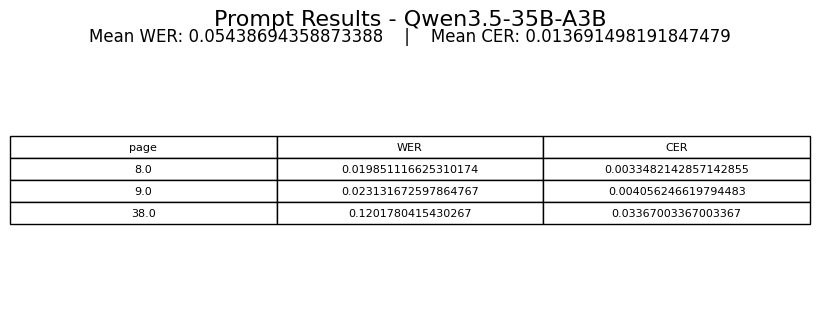

Saved: outputs/prompt_result_img/prompt_2_results.png


In [130]:
mean_wer = df_exp1["WER"].mean()
mean_cer = df_exp1["CER"].mean()

save_path = os.path.join(output_dir_result_1, "prompt_2_results.png")

fig, ax = plt.subplots(figsize=(10, len(df_exp1) * 0.45 + 2))
ax.axis("off")


fig.suptitle("Prompt Results - Qwen3.5-35B-A3B", fontsize=16, y=0.98)

summary_text = f"Mean WER: {mean_wer}    |    Mean CER: {mean_cer}"
fig.text(0.5, 0.90, summary_text, ha="center", va="center", fontsize=12)


table = ax.table(
    cellText=df_exp1.values,
    colLabels=df_exp1.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.3)

ax.set_position([0.1, 0.08, 0.8, 0.78])

fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

print("Saved:", save_path)

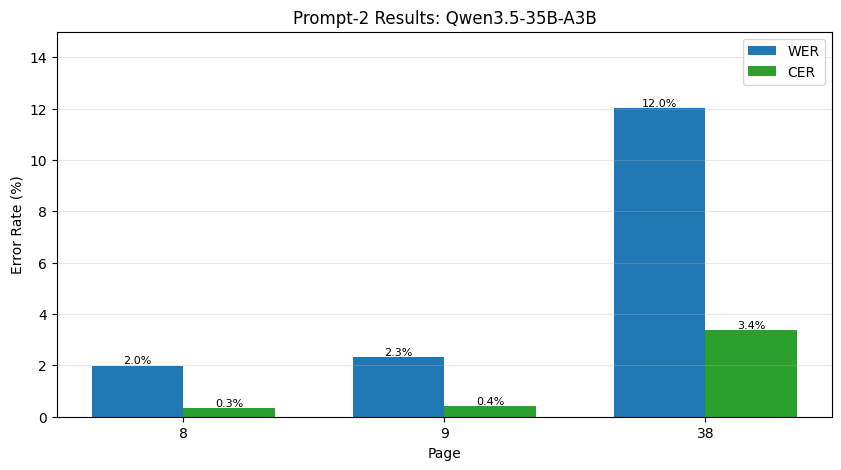

In [131]:
import numpy as np
x = np.arange(len(df_exp1))
width = 0.35

wer_pct = df_exp1["WER"] * 100
cer_pct = df_exp1["CER"] * 100

plt.figure(figsize=(10,5))


bars1 = plt.bar(
    x - width / 2,
    wer_pct,
    width,
    label="WER",
    color="#1f77b4" #blue
)

bars2 = plt.bar(
    x + width / 2,
    cer_pct,
    width,
    label="CER",
    color="#2ca02c" #gren
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.xticks(x, df_exp1["page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Prompt-2 Results: Qwen3.5-35B-A3B")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 15)
plt.yticks(np.arange(0, 16, 2))

os.makedirs(output_dir_result_1, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir_result_1,
        "experiment_1_wer_cer_by_page.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Prompt Comparison

In [132]:
prompts = {
    "prompt_1": prompt_text_1,
    "prompt_3": prompt_text_3,
}

for prompt_name, prompt_text in prompts.items():
    output_dir = f"outputs/{prompt_name}"
    os.makedirs(output_dir, exist_ok=True)

    print(f"\n===== {prompt_name} =====")

    for p in pages:
        image_path = f"prompt_images/{p}.jpg"
        output_path = os.path.join(output_dir, f"page_{p}.txt")

        output_text = run_ocr_one_image(image_path, prompt_text)

        with open(output_path, "w", encoding="utf-8") as f:
            f.write(output_text)

        print(f"Saved: {output_path}")


===== prompt_1 =====
Saved: outputs/prompt_1/page_8.txt
Saved: outputs/prompt_1/page_9.txt
Saved: outputs/prompt_1/page_38.txt

===== prompt_3 =====
Saved: outputs/prompt_3/page_8.txt
Saved: outputs/prompt_3/page_9.txt
Saved: outputs/prompt_3/page_38.txt


In [134]:
gold_base = "https://nlp.fi.muni.cz/projekty/ahisto/ocr-output/494/"

dfs = {}

for prompt in ["prompt_1", "prompt_2", "prompt_3"]:
    results = []

    for p in pages:
        gold_text = requests.get(f"{gold_base}{p}.txt").text

        pred_path = os.path.join("outputs", prompt, f"page_{p}.txt")
        with open(pred_path, "r", encoding="utf-8") as f:
            pred_text = f.read()

        gold_norm = normalize_text(gold_text)
        pred_norm = normalize_text(pred_text)

        results.append({
            "page": p,
            "WER": wer(gold_norm, pred_norm),
            "CER": cer(gold_norm, pred_norm)
        })

    dfs[prompt] = pd.DataFrame(results)

In [141]:
df_prompt1 = dfs["prompt_1"]
df_prompt2 = dfs["prompt_2"]
df_prompt3 = dfs["prompt_3"]

page = 9

wer = [
    df_prompt1.loc[df_prompt1["page"] == page, "WER"].iloc[0] * 100,
    df_prompt2.loc[df_prompt2["page"] == page, "WER"].iloc[0] * 100,
    df_prompt3.loc[df_prompt3["page"] == page, "WER"].iloc[0] * 100,
]

cer = [
    df_prompt1.loc[df_prompt1["page"] == page, "CER"].iloc[0] * 100,
    df_prompt2.loc[df_prompt2["page"] == page, "CER"].iloc[0] * 100,
    df_prompt3.loc[df_prompt3["page"] == page, "CER"].iloc[0] * 100,
]

labels = ["Prompt 1", "Prompt 2", "Prompt 3"]

## Plot Comparison

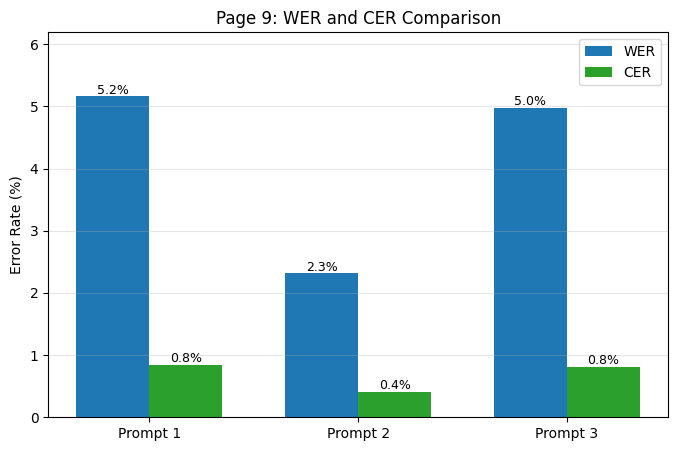

Saved: outputs/prompt_result_img/page_9_three_prompt_comparison.png


In [142]:
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width/2,
    wer,
    width,
    label="WER",
    color="#1f77b4" 
)

bars2 = plt.bar(
    x + width/2,
    cer,
    width,
    label="CER",
    color="#2ca02c"
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xticks(x, labels)
plt.xlabel("")
plt.ylabel("Error Rate (%)")
plt.title(f"Page {page}: WER and CER Comparison")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, max(max(wer), max(cer)) * 1.2)

os.makedirs(output_dir_result_1, exist_ok=True)

save_path = os.path.join(
    output_dir_result_1,
    f"page_{page}_three_prompt_comparison.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)